In [1]:
#!pip install -q langgraph langchain-ollama mcp langchain-mcp-adapters

In [1]:
import sys, os
_original_stderr = sys.stderr
errlog_path = os.path.abspath('mcp_server_stderr.log')
sys.stderr = open(errlog_path,'w')
from langchain_mcp_adapters.client import MultiServerMCPClient
sys.stderr = _original_stderr

In [2]:
%%writefile mcp_server.py
import re
import sys
from mcp.server.fastmcp import FastMCP


mcp = FastMCP("agent-tools")


@mcp.tool()
def get_knowledge(query: str) -> str:
    """
    Answer a general knowledge question using a small built-in knowledge base.
    """

    knowledge_base = {
        "python": "Python is a popular high-level programming language known for readability.",
        "langgraph": "LangGraph is a library for building stateful, multi-agent applications with LLMs.",
        "ai": "AI (Artificial Intelligence) refers to machines simulating human intelligence.",
        "mcp": "MCP (Model Context Protocol) is an open standard that lets AI applications connect to external tools and data sources in a consistent way.",
    }

    for key, value in knowledge_base.items():
        if key in query.lower():
            return value

    return "Sorry, I don't have information on that topic yet."


@mcp.tool()
def calculate(expression: str) -> str:
    """
    Evaluate a basic arithmetic expression containing numbers and
    + - * / ( ).
    """

    clean_expr = re.sub(r"[^0-9+\-*/(). ]", "", expression)

    try:
        result = eval(clean_expr)
        return f"The answer is {result}"
    except Exception:
        return "Could not calculate that expression."


@mcp.tool()
def send_email(subject: str, body: str) -> str:
    """
    Simulate sending an email (printed only, no real email is sent).
    """

    recipient = "someone@example.com"

    draft = (
        f"To: {recipient}\n"
        f"Subject: {subject}\n\n"
        f"{body}"
    )

    return f"Email sent (simulated - not actually sent):\n{draft}"


if __name__ == "__main__":
    mcp.run(transport="stdio")

Overwriting mcp_server.py


In [3]:
import re
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_ollama import ChatOllama
from langchain_mcp_adapters.client import MultiServerMCPClient

In [4]:
import sys,os
llm = ChatOllama(model="llama3.1", temperature=0)
server_path = os.path.abspath('mcp_server.py')
client = MultiServerMCPClient(
    {
        "agent_tools": {
            "command": sys.executable,
            "args": ["mcp_server.py"],
            "transport": "stdio",
            'env':dict(os.environ),
        }
    }
)

tools = await client.get_tools()
tools_by_name = {tool.name: tool for tool in tools}

print("Tools discovered from the MCP server:", list(tools_by_name.keys()))

knowledge_tool = tools_by_name["get_knowledge"]
calculator_tool = tools_by_name["calculate"]
email_tool = tools_by_name["send_email"]

Tools discovered from the MCP server: ['get_knowledge', 'calculate', 'send_email']


In [20]:
#with open(errlog_path) as f:
#    print(f.read())

In [5]:
def extract_text(tool_result):
    """Convert an MCP tool result (list of content blocks) into a plain string."""
    if isinstance(tool_result, list):
        return " ".join(
            block.get("text", "")
            for block in tool_result
            if isinstance(block, dict)
        )
    return str(tool_result)

In [6]:
class AgentState(TypedDict):
    query : str
    result : str 

In [7]:
async def router(state):
    query = state["query"]

    prompt = f"""
You are a router for a multi-agent system. Decide which single agent
should handle the user's query.

Agents:
- calculator_node for math calculations / arithmetic
- email_node for drafting or sending emails/messages
- knowledge_node for general knowledge questions

Query: "{query}"

Respond with ONLY one word, exactly one of:
calculator_node, email_node, knowledge_node
"""

    response = await llm.ainvoke(prompt)
    decision = response.content.strip().lower()

    if "calculator" in decision:
        return "calculator_node"
    elif "email" in decision:
        return "email_node"
    else:
        return "knowledge_node"

In [8]:
async def knowledge_node(state):
    """Calls the get_knowledge MCP tool directly with the user's query."""

    result = await knowledge_tool.ainvoke(
        {"query": state["query"]}
    )

    state["result"] = extract_text(result)
    return state

In [9]:
async def calculator_node(state):
    """
    Uses the LLM to pull out the arithmetic expression, then calls the
    calculate MCP tool to get the exact answer.
    """

    query = state["query"]

    prompt = f"""
Extract only the arithmetic expression from this text, using digits
and the symbols + - * / ( ) only. Return ONLY the expression,
nothing else.

Text: {query}
"""

    response = await llm.ainvoke(prompt)
    expression = response.content.strip()

    result = await calculator_tool.ainvoke(
        {"expression": expression}
    )

    state["result"] = extract_text(result)
    return state

In [10]:
async def email_node(state):
    """
    Uses the LLM to draft a subject + body, then calls the send_email
    MCP tool to (simulate) sending it.
    """

    query = state["query"]

    prompt = f"""
Draft a short, professional email based on this request.

Request: "{query}"

Respond in exactly this format:
Subject: <subject>
Body: <body>
"""

    response = await llm.ainvoke(prompt)
    content = response.content

    subject_match = re.search(r"Subject:\s*(.*)", content)
    body_match = re.search(r"Body:\s*(.*)", content, re.DOTALL)

    subject = (
        subject_match.group(1).strip()
        if subject_match
        else "Message from Multi-Agent System"
    )

    body = (
        body_match.group(1).strip()
        if body_match
        else content.strip()
    )

    result = await email_tool.ainvoke(
        {
            "subject": subject,
            "body": body,
        }
    )

    state["result"] = extract_text(result)
    return state

In [11]:
workflow = StateGraph(AgentState)

workflow.add_node("knowledge_node", knowledge_node)
workflow.add_node("calculator_node", calculator_node)
workflow.add_node("email_node", email_node)

workflow.set_conditional_entry_point(
    router,
    {
        "knowledge_node": "knowledge_node",
        "calculator_node": "calculator_node",
        "email_node": "email_node",
    },
)

workflow.add_edge("knowledge_node", END)
workflow.add_edge("calculator_node", END)
workflow.add_edge("email_node", END)

app = workflow.compile()

print("Graph compiled successfully!")

Graph compiled successfully!


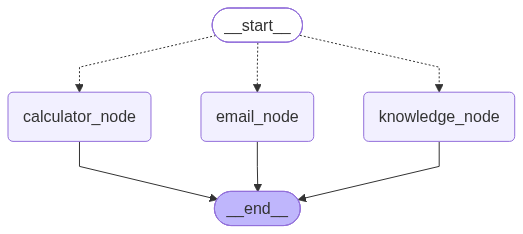

In [12]:
from IPython.display import Image, display

try: 
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("could not render graph image",e)
    print(app.get_graph().draw_mermaid())

In [16]:
user_query = input('Enter your Query:')
output = await app.ainvoke({'query':user_query,'result':""})
print(output['result'])

Enter your Query: send an email saying the meeting is at 5pm. 


Email sent (simulated - not actually sent):
To: someone@example.com
Subject: Reminder: Meeting Time

The meeting will be held at 5pm as previously scheduled. I look forward to seeing you then.
